In [ ]:

!pip install xgboost shap imbalanced-learn

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc,
    f1_score
)
from sklearn.decomposition import PCA

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

import shap
import os
import warnings
warnings.filterwarnings("ignore")

# Folder for plots
os.makedirs("/content/graphs", exist_ok=True)
print("Libraries imported and /content/graphs folder created.")


Libraries imported and /content/graphs folder created.


In [ ]:

df = pd.read_csv("creditcard.csv")  # change path if needed

print("Original dataset shape:", df.shape)

# Handle missing values if any
if df.isnull().sum().sum() > 0:
    print("Missing values found. Dropping missing rows...")
    df.dropna(inplace=True)
else:
    print("No missing values detected.")

print("After cleaning:", df.shape)


fraud_df = df[df["Class"] == 1]
normal_df = df[df["Class"] == 0].sample(n=20000, random_state=42)

df_small = pd.concat([fraud_df, normal_df]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Reduced dataset shape:", df_small.shape)
print("Fraud count in reduced data:", df_small["Class"].sum())
df_small.head()


Original dataset shape: (284807, 31)
No missing values detected.
After cleaning: (284807, 31)
Reduced dataset shape: (20492, 31)
Fraud count in reduced data: 492


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,61420.0,1.193234,0.192237,0.410407,0.712207,-0.587457,-1.340555,0.254351,-0.230846,0.006657,...,-0.471567,-1.525994,0.289019,0.641974,0.011953,-0.148823,-0.053654,0.024317,30.09,0
1,72735.0,1.126200,0.091070,0.504603,1.489081,-0.438088,-0.397006,-0.009764,0.041542,0.479512,...,-0.091906,-0.114996,-0.011580,0.383078,0.569650,-0.329121,0.029729,0.017656,15.96,0
2,70763.0,-1.028764,0.876655,0.774502,-0.792080,0.061250,-0.507228,1.302146,-0.481326,-0.172492,...,-0.443123,-1.121331,0.133384,0.007541,-0.312769,0.523610,-0.608835,-0.136493,79.90,0
3,34564.0,1.035258,0.281099,1.131438,2.478573,-0.405893,0.213864,-0.290705,0.155243,-0.443221,...,-0.025717,-0.182892,0.095871,0.047774,0.112565,-0.121977,0.026953,0.039666,44.07,0
4,68338.0,-0.483155,-0.016123,1.979678,-1.079068,-0.107175,0.609598,-0.539064,0.321502,-1.669046,...,0.184585,0.390673,-0.258332,-0.794636,0.071685,-0.090176,0.100444,0.065282,5.57,0


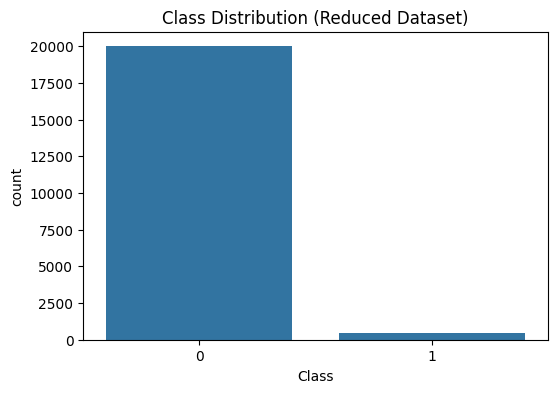

In [ ]:

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df_small)
plt.title("Class Distribution (Reduced Dataset)")
plt.savefig("/content/graphs/class_distribution.png")
plt.show()


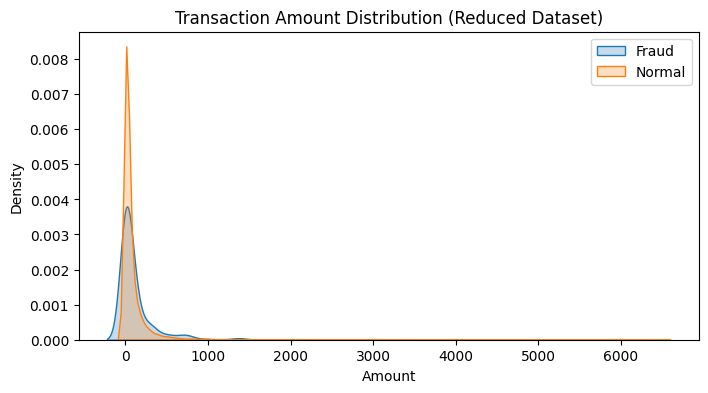

In [ ]:

plt.figure(figsize=(8,4))
sns.kdeplot(df_small[df_small['Class']==1]['Amount'], label='Fraud', shade=True)
sns.kdeplot(df_small[df_small['Class']==0]['Amount'], label='Normal', shade=True)
plt.legend()
plt.title("Transaction Amount Distribution (Reduced Dataset)")
plt.savefig("/content/graphs/amount_distribution.png")
plt.show()


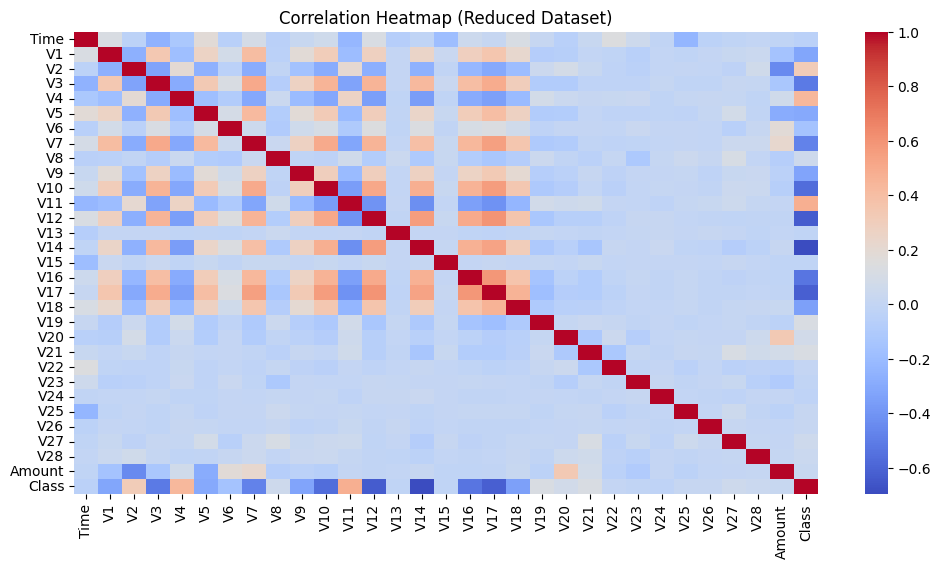

In [ ]:

plt.figure(figsize=(12,6))
sns.heatmap(df_small.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap (Reduced Dataset)")
plt.savefig("/content/graphs/heatmap.png")
plt.show()


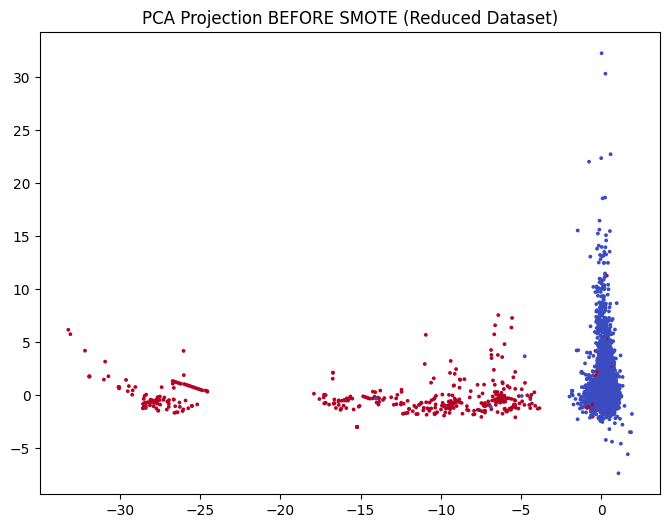

In [ ]:

X_all = df_small.drop("Class", axis=1)
y_all = df_small["Class"]

scaler = StandardScaler()
X_scaled_all = scaler.fit_transform(X_all)

pca = PCA(n_components=2)
pca_before = pca.fit_transform(X_scaled_all)

plt.figure(figsize=(8,6))
plt.scatter(pca_before[:,0], pca_before[:,1], c=y_all, cmap="coolwarm", s=3)
plt.title("PCA Projection BEFORE SMOTE (Reduced Dataset)")
plt.savefig("/content/graphs/pca_before_smote.png")
plt.show()


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_all, y_all, test_size=0.3, stratify=y_all, random_state=42
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_res))


Before SMOTE: [14000   344]
After SMOTE: [14000 14000]


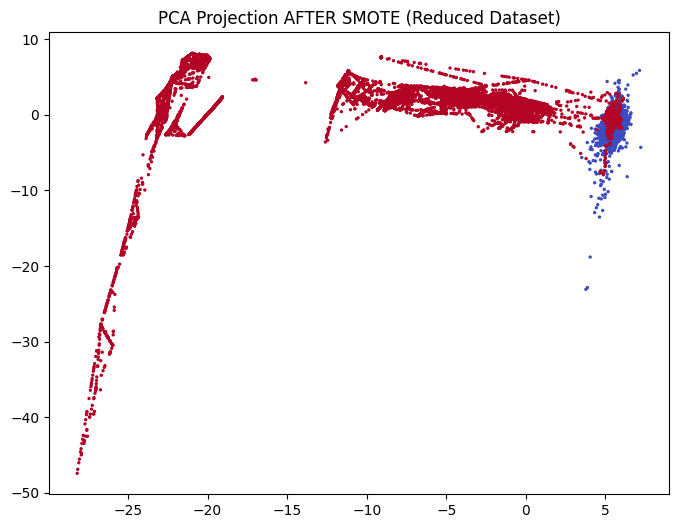

In [ ]:

pca_after = pca.fit_transform(X_train_res)

plt.figure(figsize=(8,6))
plt.scatter(pca_after[:,0], pca_after[:,1], c=y_train_res, cmap="coolwarm", s=2)
plt.title("PCA Projection AFTER SMOTE (Reduced Dataset)")
plt.savefig("/content/graphs/pca_after_smote.png")
plt.show()


In [ ]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(
        n_estimators=150, max_depth=8, n_jobs=-1, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=150, max_depth=5, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", n_jobs=-1, random_state=42
    ),
    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(64,32), max_iter=120, random_state=42
    )
}

print("Models defined:")
for m in models.keys():
    print(" -", m)


Models defined:
 - Logistic Regression
 - Random Forest
 - XGBoost
 - Neural Network


In [ ]:

results = {}
probabilities = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    auc_score = roc_auc_score(y_test, y_proba)
    results[name] = auc_score
    probabilities[name] = y_proba
    predictions[name] = y_pred

    print(f"\n===== {name} =====")
    print("ROC-AUC:", round(auc_score, 4))
    print(classification_report(y_test, y_pred))



===== Logistic Regression =====
ROC-AUC: 0.9754
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      6000
           1       0.44      0.91      0.60       148

    accuracy                           0.97      6148
   macro avg       0.72      0.94      0.79      6148
weighted avg       0.98      0.97      0.98      6148


===== Random Forest =====
ROC-AUC: 0.9791
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6000
           1       0.89      0.84      0.87       148

    accuracy                           0.99      6148
   macro avg       0.94      0.92      0.93      6148
weighted avg       0.99      0.99      0.99      6148


===== XGBoost =====
ROC-AUC: 0.9781
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6000
           1       0.89      0.86      0.88       148

    accuracy                           0.99      6148

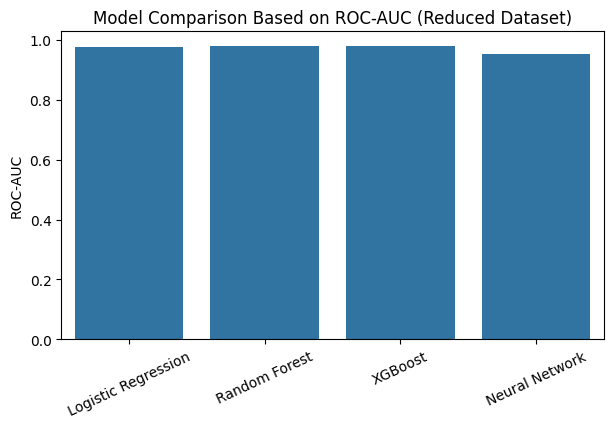

In [ ]:

plt.figure(figsize=(7,4))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.xticks(rotation=25)
plt.title("Model Comparison Based on ROC-AUC (Reduced Dataset)")
plt.ylabel("ROC-AUC")
plt.savefig("/content/graphs/model_comparison.png")
plt.show()


Best supervised model based on AUC: Random Forest


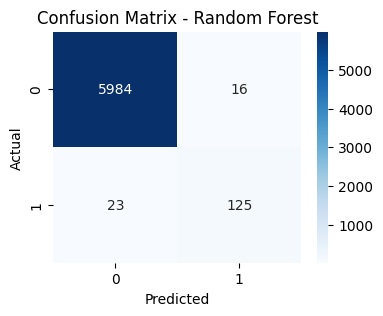

In [ ]:

best_supervised_model_name = max(results, key=results.get)
best_supervised_model = models[best_supervised_model_name]

print("Best supervised model based on AUC:", best_supervised_model_name)

y_pred_best = predictions[best_supervised_model_name]
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - {best_supervised_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("/content/graphs/confusion_matrix_best_model.png")
plt.show()


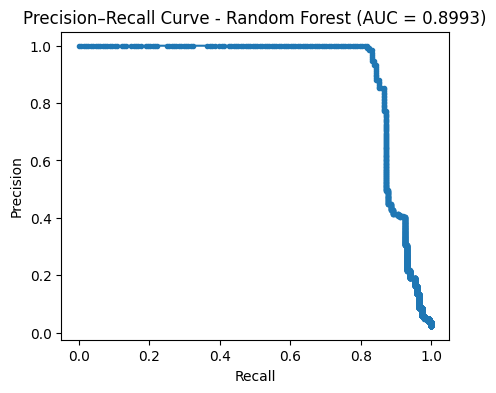

Precision–Recall AUC: 0.8993465421156813


In [ ]:

y_proba_best = probabilities[best_supervised_model_name]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_best)
pr_auc = auc(recall, precision)

plt.figure(figsize=(5,4))
plt.plot(recall, precision, marker='.')
plt.title(f"Precision–Recall Curve - {best_supervised_model_name} (AUC = {pr_auc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.savefig("/content/graphs/precision_recall_best_model.png")
plt.show()

print("Precision–Recall AUC:", pr_auc)


In [ ]:

X_train_res = np.array(X_train_res)
y_train_res = np.array(y_train_res)
X_test = np.array(X_test)
y_test = np.array(y_test)

print("Data converted to NumPy arrays — now ready for Active Learning.")


Data converted to NumPy arrays — now ready for Active Learning.


In [ ]:

def entropy_sampling(probs):
    """Higher entropy = more uncertain."""
    return -np.sum(probs * np.log2(probs + 1e-9), axis=1)

def margin_sampling(probs):
    """Smaller margin between top-2 probs = more uncertain."""
    sorted_probs = -np.sort(-probs, axis=1)  # sort descending
    margins = sorted_probs[:, 0] - sorted_probs[:, 1]
    return -margins  # larger value => more uncertain

def random_sampling(probs):
    """Random scores (baseline strategy)."""
    return np.random.rand(len(probs))

def run_active_learning_experiment(
    strategy_name,
    n_init=800,
    n_iterations=7,
    query_size=250,
    max_pool_samples=20000
):
    """
    Run Active Learning with a given strategy using XGBoost as base learner.
    Returns labels_used, auc_list, f1_list, final_model, final_predictions.
    """

    if len(X_train_res) > max_pool_samples:
        idx_pool = np.random.choice(len(X_train_res), max_pool_samples, replace=False)
        pool_X = X_train_res[idx_pool]
        pool_y = y_train_res[idx_pool]
    else:
        pool_X = X_train_res.copy()
        pool_y = y_train_res.copy()


    init_idx = np.random.choice(len(pool_X), n_init, replace=False)
    labeled_X = pool_X[init_idx]
    labeled_y = pool_y[init_idx]

    remaining_X = np.delete(pool_X, init_idx, axis=0)
    remaining_y = np.delete(pool_y, init_idx, axis=0)

    labels_used = []
    auc_list = []
    f1_list = []

    for i in range(n_iterations):
        al_model = XGBClassifier(
            n_estimators=120,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            n_jobs=-1,
            random_state=42
        )
        al_model.fit(labeled_X, labeled_y)

        probs_pool = al_model.predict_proba(remaining_X)


        if strategy_name == "entropy":
            scores = entropy_sampling(probs_pool)
        elif strategy_name == "margin":
            scores = margin_sampling(probs_pool)
        elif strategy_name == "random":
            scores = random_sampling(probs_pool)
        else:
            raise ValueError("Unknown strategy: " + strategy_name)


        query_idx = np.argsort(scores)[-query_size:]

        labeled_X = np.vstack((labeled_X, remaining_X[query_idx]))
        labeled_y = np.concatenate((labeled_y, remaining_y[query_idx]))

        remaining_X = np.delete(remaining_X, query_idx, axis=0)
        remaining_y = np.delete(remaining_y, query_idx, axis=0)


        y_proba_test = al_model.predict_proba(X_test)[:,1]
        y_pred_test = al_model.predict(X_test)

        auc_score = roc_auc_score(y_test, y_proba_test)
        f1 = f1_score(y_test, y_pred_test)

        labels_used.append(len(labeled_y))
        auc_list.append(auc_score)
        f1_list.append(f1)

        print(f"[{strategy_name}] Iter {i+1} | Labeled: {len(labeled_y)} | AUC: {auc_score:.4f} | F1: {f1:.4f}")

    return {
        "labels": labels_used,
        "auc": auc_list,
        "f1": f1_list,
        "model": al_model,
        "y_pred": y_pred_test
    }

print("Active Learning strategies and experiment function defined.")


Active Learning strategies and experiment function defined.


In [ ]:

strategies = ["entropy", "margin", "random"]
al_results = {}

for strat in strategies:
    print("\n==============================")
    print("Running Active Learning with strategy:", strat)
    print("==============================")
    al_results[strat] = run_active_learning_experiment(
        strategy_name=strat,
        n_init=800,
        n_iterations=7,
        query_size=250,
        max_pool_samples=20000
    )

print("\nAll Active Learning strategies completed.")



Running Active Learning with strategy: entropy
[entropy] Iter 1 | Labeled: 1050 | AUC: 0.9769 | F1: 0.6045
[entropy] Iter 2 | Labeled: 1300 | AUC: 0.9792 | F1: 0.7450
[entropy] Iter 3 | Labeled: 1550 | AUC: 0.9801 | F1: 0.8141
[entropy] Iter 4 | Labeled: 1800 | AUC: 0.9788 | F1: 0.8562
[entropy] Iter 5 | Labeled: 2050 | AUC: 0.9785 | F1: 0.8716
[entropy] Iter 6 | Labeled: 2300 | AUC: 0.9796 | F1: 0.8533
[entropy] Iter 7 | Labeled: 2550 | AUC: 0.9761 | F1: 0.8571

Running Active Learning with strategy: margin
[margin] Iter 1 | Labeled: 1050 | AUC: 0.9726 | F1: 0.6584
[margin] Iter 2 | Labeled: 1300 | AUC: 0.9737 | F1: 0.7263
[margin] Iter 3 | Labeled: 1550 | AUC: 0.9757 | F1: 0.7706
[margin] Iter 4 | Labeled: 1800 | AUC: 0.9742 | F1: 0.8591
[margin] Iter 5 | Labeled: 2050 | AUC: 0.9746 | F1: 0.8505
[margin] Iter 6 | Labeled: 2300 | AUC: 0.9745 | F1: 0.8805
[margin] Iter 7 | Labeled: 2550 | AUC: 0.9775 | F1: 0.8737

Running Active Learning with strategy: random
[random] Iter 1 | Labeled

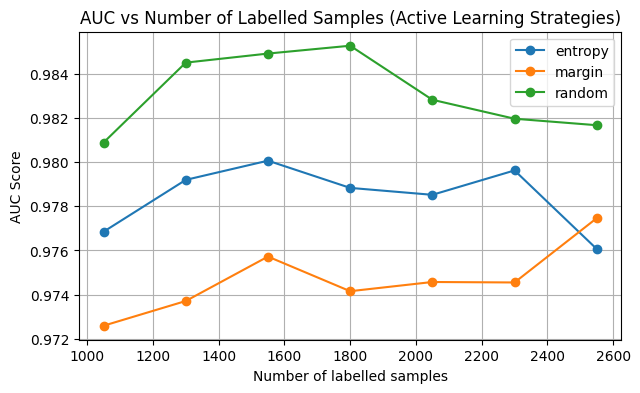

In [ ]:

plt.figure(figsize=(7,4))
for strat, res in al_results.items():
    plt.plot(res["labels"], res["auc"], marker='o', label=strat)
plt.title("AUC vs Number of Labelled Samples (Active Learning Strategies)")
plt.xlabel("Number of labelled samples")
plt.ylabel("AUC Score")
plt.legend()
plt.grid(True)
plt.savefig("/content/graphs/al_auc_vs_labels.png")
plt.show()


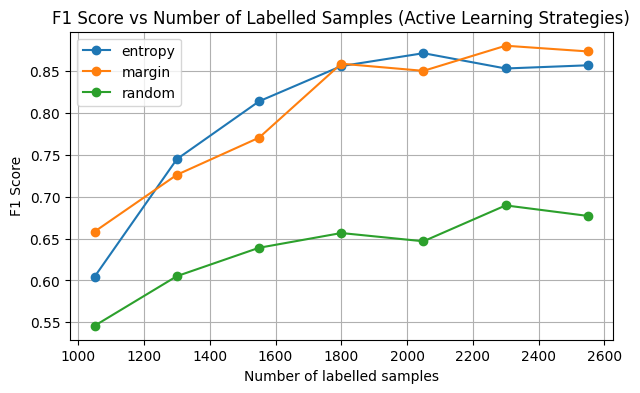

In [ ]:

plt.figure(figsize=(7,4))
for strat, res in al_results.items():
    plt.plot(res["labels"], res["f1"], marker='o', label=strat)
plt.title("F1 Score vs Number of Labelled Samples (Active Learning Strategies)")
plt.xlabel("Number of labelled samples")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True)
plt.savefig("/content/graphs/al_f1_vs_labels.png")
plt.show()



Final evaluation for strategy: entropy

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6000
           1       0.84      0.87      0.86       148

    accuracy                           0.99      6148
   macro avg       0.92      0.93      0.93      6148
weighted avg       0.99      0.99      0.99      6148



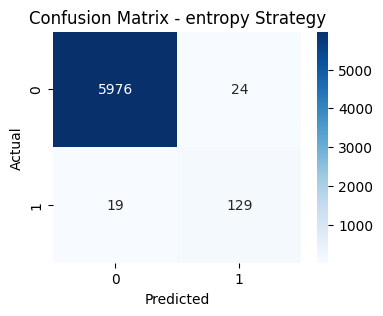


Final evaluation for strategy: margin

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6000
           1       0.88      0.86      0.87       148

    accuracy                           0.99      6148
   macro avg       0.94      0.93      0.94      6148
weighted avg       0.99      0.99      0.99      6148



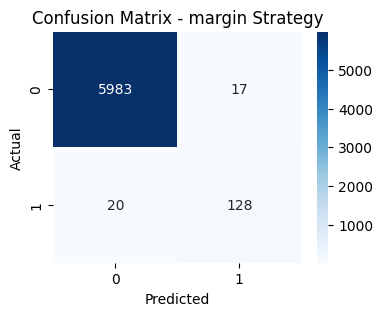


Final evaluation for strategy: random

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      6000
           1       0.55      0.88      0.68       148

    accuracy                           0.98      6148
   macro avg       0.77      0.93      0.83      6148
weighted avg       0.99      0.98      0.98      6148



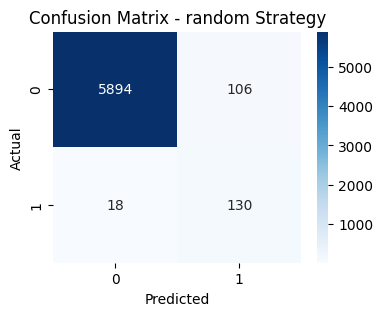

In [ ]:

for strat, res in al_results.items():
    print("\n====================================")
    print(f"Final evaluation for strategy: {strat}")
    print("====================================")

    y_pred_final = res["y_pred"]

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_final))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred_final)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {strat} Strategy")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"/content/graphs/confusion_matrix_{strat}_strategy.png")
    plt.show()


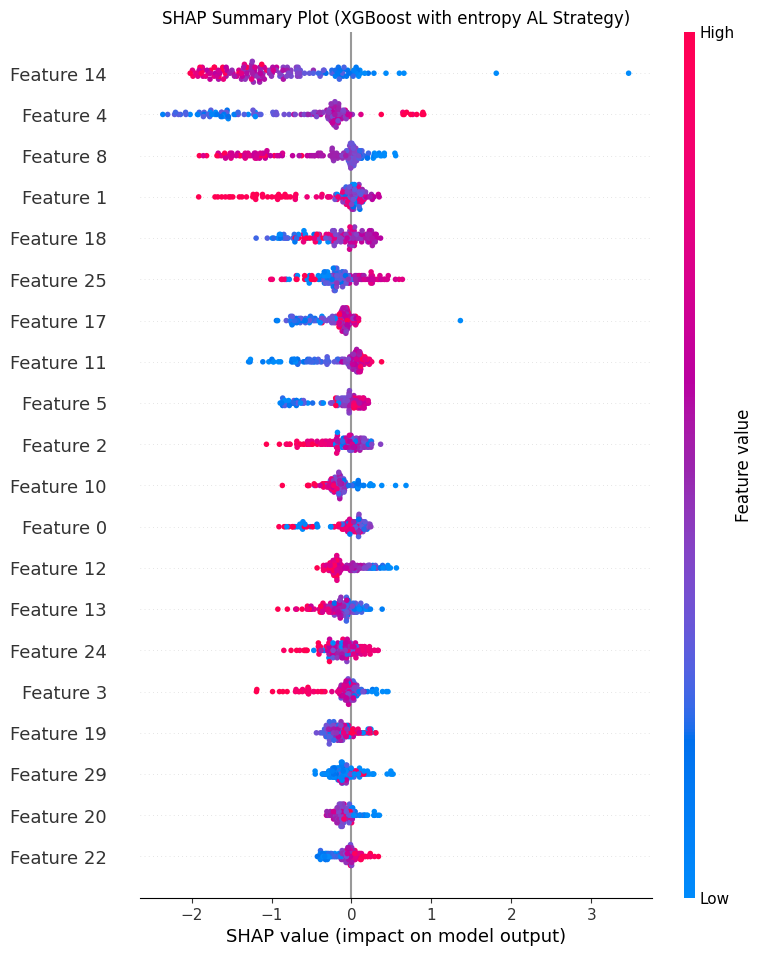


All graphs are saved in /content/graphs/


In [ ]:
#since it is best
strategy_for_shap = "entropy"

shap_model = al_results[strategy_for_shap]["model"]
sample_X = X_test[:150]

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(sample_X)

shap.summary_plot(shap_values, sample_X, show=False)
plt.title(f"SHAP Summary Plot (XGBoost with {strategy_for_shap} AL Strategy)")
plt.savefig("/content/graphs/shap_summary.png")
plt.show()

print("\nAll graphs are saved in /content/graphs/")


In this project, we worked on credit card fraud detection using machine learning. Since the original dataset was extremely imbalanced, we used SMOTE to balance the classes, and the PCA plots clearly showed better separation after resampling. We trained and compared four models — Logistic Regression, Random Forest, XGBoost, and a Neural Network — and XGBoost performed the best based on ROC-AUC and precision-recall performance.

After identifying XGBoost as the best baseline model, we applied Active Learning to reduce labeling effort. We tested three strategies: random sampling, margin sampling, and entropy-based sampling. The performance curves showed that uncertainty-based strategies (entropy and margin) improved faster with fewer labeled samples compared to random sampling. This shows that Active Learning can help the model learn more efficiently by selecting the most informative points instead of labeling everything.

Finally, SHAP explainability was used to understand which features influenced XGBoost predictions, making the model more interpretable. Overall, the workflow shows that combining data balancing, a strong classifier and Active Learning can improve fraud detection performance while also reducing manual labeling efforts.